### Plotting the Normalised Frequency for ech length in query.bed

Calculating the fragment length and normalising them.

In [1]:
import matplotlib.pyplot as plt
from collections import defaultdict
import pandas as pd
import random

fragment_counts = defaultdict(int)
total_fragments = 0

with open("query.bed", "r") as f:
    for line in f:
        cols = line.strip().split()
        start = int(cols[1])
        end = int(cols[2])
        length = end - start
        if length > 0:
            fragment_counts[length] += 1
            total_fragments += 1

lengths = sorted(fragment_counts)
normalized_freqs = [fragment_counts[l] / total_fragments for l in lengths]

Plotting the Fragment Length vs. Normalised Frequency.

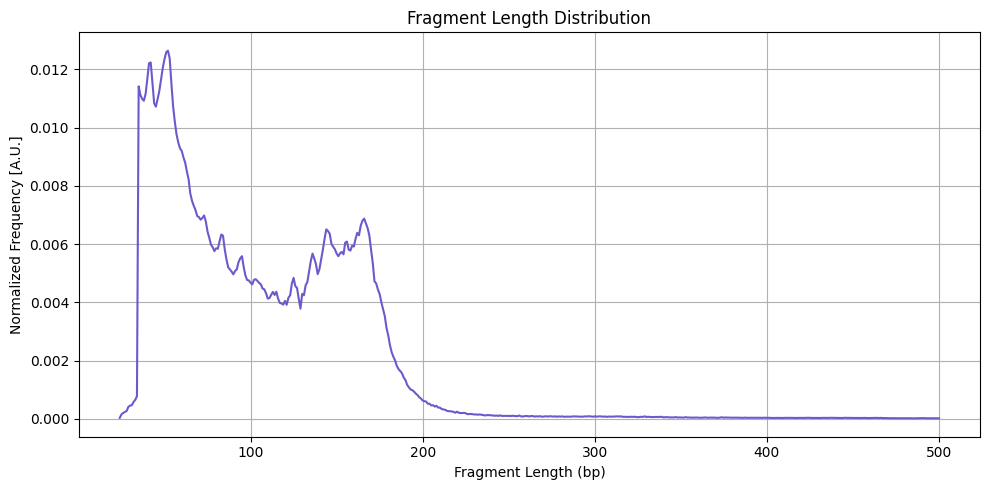

In [2]:
plt.figure(figsize=(10, 5))
plt.plot(lengths, normalized_freqs, color='slateblue')
plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Fragment Length Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

### Rescaling of query along the reference.

Loading query.bed and compute raw length distribution.

In [3]:
query_fragments = []  # fragment lengths
query_records = []    # full lines of bed entries

with open("query.bed", "r") as f:
    for line in f:
        cols = line.strip().split()
        if len(cols) < 3:
            continue
        try:
            start = int(cols[1])
            end = int(cols[2])
            length = end - start
            if length > 0:
                query_fragments.append(length)
                query_records.append(line)
        except ValueError:
            continue


Loading the reference data and normalising it.

In [4]:
reference_distribution = {}
with open("reference.hist", "r") as ref_file:
    for line in ref_file:
        parts = line.strip().split()
        if len(parts) >= 2:
            length = int(parts[0])
            freq = float(parts[1])
            reference_distribution[length] = freq
            
total_ref = sum(reference_distribution.values())
normalized_ref = {l: f / total_ref for l, f in reference_distribution.items()}

Subsampling queries to match it with reference.

In [5]:
query_by_length = defaultdict(list)
for idx, length in enumerate(query_fragments):
    query_by_length[length].append(idx)

target_total = len(query_fragments)
rescaled_indices = []

for length, ref_prob in normalized_ref.items():
    target_count = int(ref_prob * target_total)
    available = query_by_length.get(length, [])
    sampled = random.sample(available, min(target_count, len(available)))
    rescaled_indices.extend(sampled)

rescaled_query_fragments = [query_fragments[i] for i in rescaled_indices]

Computing the frequency distributions for query, reference and resampled query.

In [6]:
# Original query
original_counts = defaultdict(int)
for l in query_fragments:
    original_counts[l] += 1
total_original = len(query_fragments)
original_lengths = sorted(original_counts)
original_freqs = [original_counts[l] / total_original for l in original_lengths]

# Reference
ref_lengths = sorted(normalized_ref)
ref_freqs = [normalized_ref[l] for l in ref_lengths]

# Rescaled query
rescaled_counts = defaultdict(int)
for l in rescaled_query_fragments:
    rescaled_counts[l] += 1
total_rescaled = len(rescaled_query_fragments)
rescaled_lengths = sorted(rescaled_counts)
rescaled_freqs = [rescaled_counts[l] / total_rescaled for l in rescaled_lengths]

Plotting the original query vs. reference vs rescaled query.

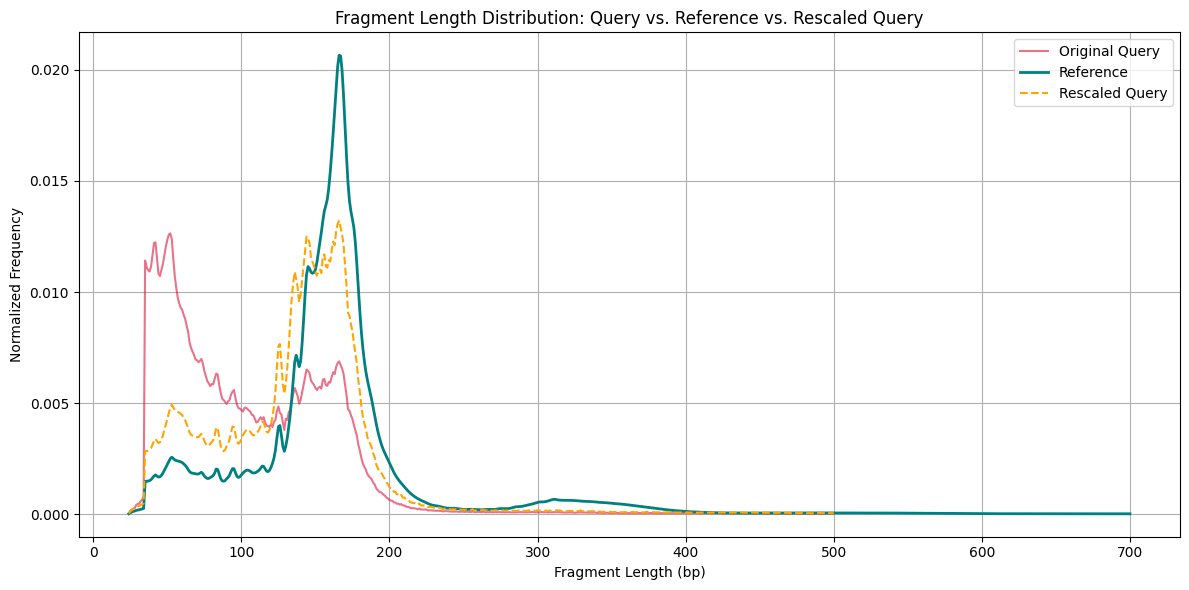

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(original_lengths, original_freqs, label="Original Query", color='crimson', alpha=0.6)
plt.plot(ref_lengths, ref_freqs, label="Reference", color='teal', linewidth=2)
plt.plot(rescaled_lengths, rescaled_freqs, label="Rescaled Query", color='orange', linestyle='--')

plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency")
plt.title("Fragment Length Distribution: Query vs. Reference vs. Rescaled Query")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Plotting with Binned Sampling.

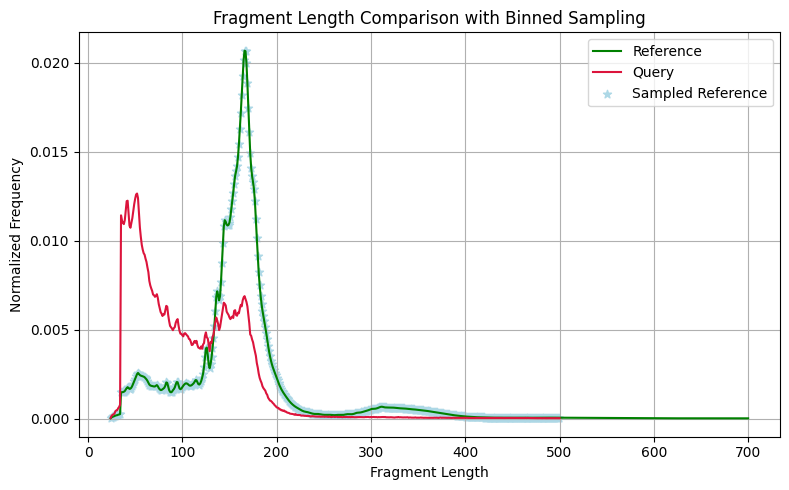

In [10]:
query_df = pd.read_csv('query.bed', sep='\t', header=None)
query_df.columns = ['Chrom', 'Start', 'End', 'Length', 'Dot', 'Strand']  # Adjust as needed

reference_data = pd.read_csv('reference.hist', header=None, sep='\t')

reference_data[0] = pd.to_numeric(reference_data[0], errors='coerce')

# Define bins and labels
bin_edges = list(range(0, 510, 10))
bin_labels = [f"{i}-{i+10}" for i in range(0, 500, 10)]

# Add bin labels
query_df['Bin'] = pd.cut(query_df['Length'], bins=bin_edges, labels=bin_labels, right=False)
reference_data['Bin'] = pd.cut(reference_data[0], bins=bin_edges, labels=bin_labels, right=False)

# Count how many items fall into each bin
query_bin_counts = query_df['Bin'].value_counts().sort_index()
reference_bin_counts = reference_data['Bin'].value_counts().sort_index()

# Initialize list to store sampled rows from reference
matched_sample_rows = []

# Match query and reference samples by bin
for label in bin_labels:
    count_query = query_bin_counts.get(label, 0)
    count_reference = reference_bin_counts.get(label, 0)
    sample_size = min(count_query, count_reference)
    
    if sample_size > 0:
        reference_subset = reference_data[reference_data['Bin'] == label]
        sampled_subset = reference_subset.sample(n=sample_size, random_state=42)
        matched_sample_rows.append(sampled_subset)

# Combine sampled rows
if matched_sample_rows:
    sampled_reference_df = pd.concat(matched_sample_rows, ignore_index=True)
else:
    sampled_reference_df = pd.DataFrame(columns=reference_data.columns)

# Count frequency of each length
length_counts = query_df['Length'].value_counts().sort_index()

# Normalize it
length_freq = length_counts / length_counts.sum()

# Convert to DataFrame
query_freq_df = pd.DataFrame({'Length': length_freq.index, 'Frequency': length_freq.values})

# Plot results
plt.figure(figsize=(8, 5))
plt.plot(reference_data[0], reference_data[1], color='green', label='Reference')
plt.plot(query_freq_df['Length'], query_freq_df['Frequency'], color='crimson', label='Query')
plt.scatter(sampled_reference_df[0], sampled_reference_df[1], color='lightblue', marker='*', label='Sampled Reference')

plt.title('Fragment Length Comparison with Binned Sampling')
plt.xlabel('Fragment Length')
plt.ylabel('Normalized Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()